In [17]:
# 데이터 처리 및 분석
import pandas as pd
import ast
import numpy as np
from datetime import datetime, timedelta
import warnings
import re
from tqdm import tqdm
from wordcloud import WordCloud
from collections import Counter
from kiwipiepy import Kiwi
import os

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import platform

# ── 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# ── 출력 설정 ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.random.seed(42)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("=" * 60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [ ]:
# # ── 셀 1: 모듈 로드 + 골든셋 생성 ─────────────────────────────
# import importlib, sys
# sys.path.insert(0, './송원우')

# import absa_sampling
# importlib.reload(absa_sampling)   # 모듈 수정 후 재실행 시 변경 즉시 반영

# stats = absa_sampling.build_golden_set(
#     parquet_path     = '/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/preprocessed_absa.parquet',
#     output_path      = '/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/absa_golden_set_1000.xlsx',
#     n_per_brand      = 250,    # 4 브랜드 × 250 = 1,000건
#     low_rating_ratio = 0.5,    # 1-3점 50% (별점 편향 보정)
#     min_len          = 20,     # 정보량 확보
#     seed             = 260504,
# )
# stats


{'total': 1000,
 'output_path': '/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/absa_golden_set_1000.xlsx',
 'brand_dist': {'젝시믹스': 250, '안다르': 250, 'FILA': 250, '룰루레몬': 250},
 'rating_dist': {1: 88, 2: 62, 3: 350, 4: 53, 5: 447},
 'low_rating': 500,
 'high_rating': 500}

In [ ]:
# # ── 셀 2: 샘플 통계 검증 ─────────────────────────────────────
# import pandas as pd

# df_sample = absa_sampling.sample_golden_set(
#     parquet_path='/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/preprocessed_absa.parquet',
#     seed=260504,
# )

# print('=== 브랜드 × 별점대 교차표 ===')
# df_sample['rating_band'] = pd.cut(
#     df_sample['rating'], bins=[0, 3, 5], labels=['1-3점', '4-5점'],
# )
# print(pd.crosstab(df_sample['brand'], df_sample['rating_band'], margins=True))

# print('\n=== content_len 분포 ===')
# print(df_sample['content_len'].describe().round(1))

# print('\n=== 카테고리(cat1) 다양성 ===')
# print(df_sample['cat1'].value_counts().head(10))

# print('\n=== 라벨 컬럼 확인 (모두 빈 값이어야 함) ===')
# for asp in absa_sampling.ASPECTS:
#     print(f'  {asp:18s}: 빈 값 {(df_sample[asp] == "").sum()}건')


=== 브랜드 × 별점대 교차표 ===
rating_band  1-3점  4-5점   All
brand                        
FILA          125   125   250
룰루레몬          125   125   250
안다르           125   125   250
젝시믹스          125   125   250
All           500   500  1000

=== content_len 분포 ===
count    1000.0
mean       73.3
std        81.2
min        20.0
25%        38.0
50%        55.0
75%        82.0
max      1384.0
Name: content_len, dtype: float64

=== 카테고리(cat1) 다양성 ===
cat1
하의      233
신발      216
상의      175
세트상품    141
용품       90
언더웨어     58
아우터      52
스윔웨어     16
전신류       8
이너웨어      7
Name: count, dtype: int64

=== 라벨 컬럼 확인 (모두 빈 값이어야 함) ===
  핏/사이즈             : 빈 값 1000건
  소재/내구성            : 빈 값 1000건
  기능성               : 빈 값 1000건
  디자인               : 빈 값 1000건
  브랜드/헤리티지          : 빈 값 1000건
  가격/가치             : 빈 값 1000건


In [ ]:
# # ── 셀 3: 샘플 5건 미리보기 ───────────────────────────────────
# df_sample[['brand','rating','content_len','content']].head(5)


,brand,rating,content_len,content
0,젝시믹스,5,131,키 177 몸무게 95키로 배가 조금 나온 비만형 체형 입니다 xxl사이즈 입으니 ...
1,젝시믹스,1,56,아니 원단이 얼마나 후진지 주름보세요 빨면 펴질줄 알았는데 그대로입니다 운동복을 입...
2,안다르,5,74,시원하고 편하면서 잘잡아줘서 너무좋아요.허리말림도 심하지않고 와이존커버가 잘돼서 민...
3,FILA,3,38,발볼 작고 발등낮은 사람을 위한 신발 반업했는데도 작습니다 신다보면 언젠가는 늘어나겠죠
4,룰루레몬,3,46,신축성 &이쁜핏 기장도 줄일필요없이 잘맞구 신축성도 좋은 질감이예요\n골프할때도 평...


In [ ]:
# # ── 셀 4: xlsx 파일 확인 (시트 구조) ──────────────────────────
# from openpyxl import load_workbook
# wb = load_workbook('/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/absa_golden_set_1000.xlsx', read_only=True)
# print('시트 목록:', wb.sheetnames)
# ws = wb['라벨링']
# print(f'라벨링 시트: {ws.max_row}행 × {ws.max_column}열')
# print('헤더 (2행):', [c.value for c in ws[2]])
# wb.close()


시트 목록: ['가이드라인', '라벨링']
라벨링 시트: 1002행 × 17열
헤더 (2행): ['sample_idx', 'review_id', 'brand', 'cat1', 'cat2', 'product_name', 'rating', 'content_len', 'content_clean', 'content', '핏/사이즈', '소재/내구성', '기능성', '디자인', '브랜드/헤리티지', '가격/가치', '메모']


##### 라벨링 데이터셋 로드, 정규화, 단일 라벨링 통계

##### k 측정용 데이터셋 추출

In [ ]:
# # ── κ 측정용 교차 재라벨링 샘플 추출 ─────────────────────────
# path = '/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/absa_golden_set_1000_done.xlsx'
# ASPECTS = ['핏/사이즈', '소재/내구성', '기능성', '디자인', '브랜드/헤리티지', '가격/가치']

# df = pd.read_excel(path, sheet_name='라벨링', header=1)

# # 라벨러 구간 분리
# df_l1 = df[df['sample_idx'] <= 500].copy()   # 라벨러 1 담당
# df_l2 = df[df['sample_idx'] >  500].copy()   # 라벨러 2 담당

# # 각 구간에서 50건 랜덤 추출 → 100건 교차 검증 풀
# sample_from_l1 = df_l1.sample(50, random_state=260504)  # 라벨러 2가 재라벨링할 구간
# sample_from_l2 = df_l2.sample(50, random_state=260504)  # 라벨러 1이 재라벨링할 구간
# overlap_pool   = pd.concat([sample_from_l1, sample_from_l2]).sort_values('sample_idx').reset_index(drop=True)

# print(f'교차 검증 풀: {len(overlap_pool)}건')
# print(f'  라벨러 1 구간(1-500)에서 {len(sample_from_l1)}건  → 라벨러 2가 재라벨링')
# print(f'  라벨러 2 구간(501-1000)에서 {len(sample_from_l2)}건 → 라벨러 1이 재라벨링')

# # 재라벨링용 xlsx 생성 (기존 라벨 컬럼 비워서 저장)
# overlap_blank = overlap_pool.copy()
# for col in ASPECTS:
#     overlap_blank[col] = ''   # 기존 라벨 제거 → 독립 라벨링 보장
# overlap_blank['메모'] = ''

# out_path = '/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/kappa_overlap_100.xlsx'
# overlap_blank.to_excel(out_path, index=False)
# print(f'\n저장 완료: {out_path}')
# print('→ 두 라벨러가 이 파일을 각자 독립적으로 채운 뒤 아래 셀 실행')

교차 검증 풀: 100건
  라벨러 1 구간(1-500)에서 50건  → 라벨러 2가 재라벨링
  라벨러 2 구간(501-1000)에서 50건 → 라벨러 1이 재라벨링

저장 완료: /Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/kappa_overlap_100.xlsx
→ 두 라벨러가 이 파일을 각자 독립적으로 채운 뒤 아래 셀 실행


##### 1차 Cohen's k 계산

In [21]:
# ── κ 계산 (수정 버전) ─────────────────────────────────────────
from sklearn.metrics import cohen_kappa_score
import numpy as np
import pandas as pd

BASE    = '/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/'
ASPECTS = ['핏/사이즈', '소재/내구성', '기능성', '디자인', '브랜드/헤리티지', '가격/가치']

def normalize(df):
    for col in ASPECTS:
        df[col] = df[col].fillna('X').astype(str).str.upper().str.strip()
        df.loc[~df[col].isin({'P','N','U','X'}), col] = 'X'
    return df

# 원본 라벨 (done.xlsx) — 진짜 L1·L2 원본
done = normalize(pd.read_excel(BASE + 'absa_golden_set_1000_done.xlsx', sheet_name='라벨링', header=1))
done = done.set_index('sample_idx')

# 신규 라벨 파일
new_l1 = normalize(pd.read_excel(BASE + 'kappa_overlap_100_L1.xlsx')).set_index('sample_idx')
new_l2 = normalize(pd.read_excel(BASE + 'kappa_overlap_100_L2.xlsx')).set_index('sample_idx')

# 라벨러 1이 새로 채운 구간: sample_idx > 500 (원래 L2 담당)
l1_ids = new_l1[new_l1.index > 500].index                    # 50건
# 라벨러 2가 새로 채운 구간: sample_idx <= 500 (원래 L1 담당)
l2_ids = new_l2[new_l2.index <= 500].index                   # 48건

print(f'비교 가능 구간: L1신규={len(l1_ids)}건 + L2신규={len(l2_ids)}건 = {len(l1_ids)+len(l2_ids)}건\n')

# 비교쌍 구성
# [그룹A] L2 원본(done) vs L1 신규 → sample_idx > 500
# [그룹B] L1 원본(done) vs L2 신규 → sample_idx <= 500
kappa_results = {}
print("=== 속성별 Cohen's κ ===")
for asp in ASPECTS:
    # 그룹A
    ya_orig = done.loc[l1_ids, asp]            # L2 원본
    ya_new  = new_l1.loc[l1_ids, asp]          # L1 신규
    # 그룹B
    yb_orig = done.loc[l2_ids, asp]            # L1 원본
    yb_new  = new_l2.loc[l2_ids, asp]          # L2 신규

    y_ref = pd.concat([ya_orig, yb_orig])      # 원본 라벨 합치기
    y_new = pd.concat([ya_new,  yb_new])       # 신규 라벨 합치기

    k = cohen_kappa_score(y_ref, y_new)
    kappa_results[asp] = round(k, 4)
    flag = '✅' if k >= 0.75 else ('⚠️' if k >= 0.60 else '❌')
    print(f'  {flag}  {asp:18s}: κ = {k:.4f}')

macro_k = round(np.mean(list(kappa_results.values())), 4)
kappa_results['MACRO_AVG'] = macro_k
print(f'\n  Macro-avg κ = {macro_k}  (기준 ≥ 0.75)')

# 불일치 케이스 상세 확인
print('\n=== 속성별 불일치 건수 ===')
for asp in ASPECTS:
    ya_orig = done.loc[l1_ids, asp]
    ya_new  = new_l1.loc[l1_ids, asp]
    yb_orig = done.loc[l2_ids, asp]
    yb_new  = new_l2.loc[l2_ids, asp]
    ref = pd.concat([ya_orig, yb_orig])
    new = pd.concat([ya_new,  yb_new])
    mismatch = (ref != new).sum()
    total    = len(ref)
    print(f'  {asp:18s}: {mismatch}/{total}건 불일치  ({mismatch/total*100:.1f}%)')


비교 가능 구간: L1신규=50건 + L2신규=50건 = 100건

=== 속성별 Cohen's κ ===
  ⚠️  핏/사이즈             : κ = 0.6679
  ❌  소재/내구성            : κ = 0.5913
  ❌  기능성               : κ = 0.5586
  ⚠️  디자인               : κ = 0.6248
  ❌  브랜드/헤리티지          : κ = 0.1612
  ⚠️  가격/가치             : κ = 0.6867

  Macro-avg κ = 0.5484  (기준 ≥ 0.75)

=== 속성별 불일치 건수 ===
  핏/사이즈             : 23/100건 불일치  (23.0%)
  소재/내구성            : 23/100건 불일치  (23.0%)
  기능성               : 25/100건 불일치  (25.0%)
  디자인               : 20/100건 불일치  (20.0%)
  브랜드/헤리티지          : 52/100건 불일치  (52.0%)
  가격/가치             : 5/100건 불일치  (5.0%)


##### 2차 Cohen's k 계산

In [3]:
# ── Cell 1: P1/P2 검토 결과 병합 → v2.1 라벨셋 구축 ──────────────
import importlib, sys, pandas as pd, numpy as np
sys.path.insert(0, './송원우')

DATA = '/Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/'
ASPECTS = ['핏/사이즈', '소재/내구성', '기능성', '디자인', '브랜드/헤리티지', '가격/가치']
VALID = {'P', 'N', 'X'}

# ── 1. v2 베이스 로드 ──────────────────────────────────────────────
df_v2 = pd.read_excel(DATA + 'absa_golden_set_1000_v2.xlsx')
df_v21 = df_v2.copy()

# ── 2. P1/P2 검토 파일 로드 (long format, header=1) ───────────────
review_files = {
    'P1_L1': DATA + 'absa_relabel_P1_L1.xlsx',
    'P1_L2': DATA + 'absa_relabel_P1_L2.xlsx',
    'P2_L1': DATA + 'absa_relabel_P2_spotcheck_L1.xlsx',
    'P2_L2': DATA + 'absa_relabel_P2_spotcheck_L2.xlsx',
}

dfs = []
for tag, path in review_files.items():
    df = pd.read_excel(path, sheet_name='검토', header=1)
    df['_source'] = tag
    dfs.append(df[['sample_idx', '속성', '최종라벨', '_source']])

corrections_long = pd.concat(dfs, ignore_index=True)

# ── 3. 정규화 (strip, upper, 유효값 아니면 NaN 처리) ──────────────
corrections_long['최종라벨'] = (
    corrections_long['최종라벨']
    .astype(str).str.strip().str.upper()
    .where(lambda s: s.isin(VALID))
)

# 중복 처리: 같은 (sample_idx, 속성)가 P1·P2 양쪽에 있으면 P1 우선
priority = {'P1_L1': 1, 'P1_L2': 1, 'P2_L1': 2, 'P2_L2': 2}
corrections_long['_priority'] = corrections_long['_source'].map(priority)
corrections_long = (
    corrections_long
    .sort_values('_priority')
    .drop_duplicates(subset=['sample_idx', '속성'], keep='first')
)

# ── 4. Wide pivot ──────────────────────────────────────────────────
corrections_wide = (
    corrections_long
    .pivot(index='sample_idx', columns='속성', values='최종라벨')
    .reindex(columns=ASPECTS)
)

# ── 5. v2.1 업데이트 ──────────────────────────────────────────────
df_v21 = df_v21.set_index('sample_idx')
for asp in ASPECTS:
    if asp in corrections_wide.columns:
        mask = corrections_wide[asp].notna()
        df_v21.loc[corrections_wide.index[mask], asp] = corrections_wide.loc[mask, asp].values

df_v21 = df_v21.reset_index()

# ── 6. 변경 요약 ──────────────────────────────────────────────────
df_v2_idx = df_v2.set_index('sample_idx')
df_v21_idx = df_v21.set_index('sample_idx')

change_summary = {}
total_changed = 0
for asp in ASPECTS:
    before = df_v2_idx[asp]
    after  = df_v21_idx[asp]
    changed = (before != after) & after.notna()
    change_summary[asp] = changed.sum()
    total_changed += changed.sum()

print("=== v2 → v2.1 라벨 변경 요약 ===")
for asp, n in change_summary.items():
    print(f"  {asp:<12}: {n:>3}건 변경")
print(f"\n  총 변경: {total_changed}건 / {len(corrections_long.dropna(subset=['최종라벨']))}건 검토됨")

# ── 7. v2.1 저장 ──────────────────────────────────────────────────
out_path = DATA + 'absa_golden_set_1000_v21.xlsx'
df_v21.to_excel(out_path, index=False)
print(f"\n저장 완료 → {out_path}")
print(df_v21[ASPECTS].apply(pd.Series.value_counts).fillna(0).astype(int))

=== v2 → v2.1 라벨 변경 요약 ===
  핏/사이즈       :   9건 변경
  소재/내구성      :  10건 변경
  기능성         :  18건 변경
  디자인         :  16건 변경
  브랜드/헤리티지    :  46건 변경
  가격/가치       :   9건 변경

  총 변경: 108건 / 362건 검토됨

저장 완료 → /Users/wonwoo_mac/Desktop/SPARTA_PROJECT_4TH_E_COMMERCE/송원우/final_data/absa_golden_set_1000_v21.xlsx
   핏/사이즈  소재/내구성  기능성  디자인  브랜드/헤리티지  가격/가치
N    233     175  107   72       157     40
P    338     279  435  425       423     49
X    429     546  458  503       420    911


In [4]:
# ── Cell 2: Cohen's κ v2.1 기반 재측정 ───────────────────────────
from sklearn.metrics import cohen_kappa_score

# ── 1. 교차 라벨 로드 ─────────────────────────────────────────────
df_l1 = pd.read_excel(DATA + 'kappa_overlap_100_L1.xlsx')  # L1이 채운 >500 구간
df_l2 = pd.read_excel(DATA + 'kappa_overlap_100_L2.xlsx')  # L2이 채운 <=500 구간

def normalize_labels(df, aspects=ASPECTS):
    for asp in aspects:
        df[asp] = (
            df[asp].astype(str).str.strip().str.upper()
            .where(lambda s: s.isin(VALID))
        )
    return df

df_l1 = normalize_labels(df_l1)
df_l2 = normalize_labels(df_l2)

# ── 2. v2.1 원본 라벨 (set_index for fast lookup) ─────────────────
v21 = df_v21.set_index('sample_idx')

# ── 3. κ 계산 함수 ────────────────────────────────────────────────
def compute_kappa(orig_series, cross_series, labels=None):
    """NaN 제외 후 cohen_kappa_score 계산"""
    valid = orig_series.notna() & cross_series.notna()
    if valid.sum() < 5:
        return np.nan, valid.sum()
    y1 = orig_series[valid].values
    y2 = cross_series[valid].values
    k = cohen_kappa_score(y1, y2, labels=['P', 'N', 'X'])
    return k, valid.sum()

results = {}

for asp in ASPECTS:
    # Group A: idx>500 → 원본=L2(v2.1), 교차=L1
    l1_gt500 = df_l1[df_l1['sample_idx'] > 500].set_index('sample_idx')
    shared_a = l1_gt500.index.intersection(v21.index)
    orig_a  = v21.loc[shared_a, asp]
    cross_a = l1_gt500.loc[shared_a, asp]

    # Group B: idx<=500 → 원본=L1(v2.1), 교차=L2
    l2_le500 = df_l2[df_l2['sample_idx'] <= 500].set_index('sample_idx')
    shared_b = l2_le500.index.intersection(v21.index)
    orig_b  = v21.loc[shared_b, asp]
    cross_b = l2_le500.loc[shared_b, asp]

    # 합산
    orig_all  = pd.concat([orig_a,  orig_b])
    cross_all = pd.concat([cross_a, cross_b])

    k, n = compute_kappa(orig_all, cross_all)
    results[asp] = {'kappa': k, 'n_pairs': n}

# ── 4. 결과 출력 ──────────────────────────────────────────────────
print("=" * 55)
print(f"{'속성':<14} {'κ':>7}  {'해석':>12}  {'n':>5}")
print("-" * 55)

def interpret(k):
    if np.isnan(k): return "측정불가"
    if k < 0:       return "Poor"
    if k < 0.20:    return "Slight"
    if k < 0.40:    return "Fair"
    if k < 0.61:    return "Moderate"
    if k < 0.81:    return "Substantial"
    return "Almost Perfect"

kappas = []
for asp, r in results.items():
    k = r['kappa']
    if not np.isnan(k): kappas.append(k)
    print(f"  {asp:<12} {k:>7.4f}  {interpret(k):>12}  {r['n_pairs']:>5}건")

macro_k = np.mean(kappas) if kappas else np.nan
print("=" * 55)
print(f"  {'Macro κ':<12} {macro_k:>7.4f}  {interpret(macro_k):>12}")
print()
print("목표 기준: κ ≥ 0.65 (Substantial, 본 작업 진입 가능)")


속성                   κ            해석      n
-------------------------------------------------------
  핏/사이즈         0.7407   Substantial     48건
  소재/내구성        0.5965      Moderate     35건
  기능성           0.2932          Fair     44건
  디자인           0.4569      Moderate     42건
  브랜드/헤리티지      0.3879          Fair     33건
  가격/가치         0.3043          Fair      8건
  Macro κ       0.4633      Moderate

목표 기준: κ ≥ 0.65 (Substantial, 본 작업 진입 가능)


##### 속셩별 confusion matrix 시각화

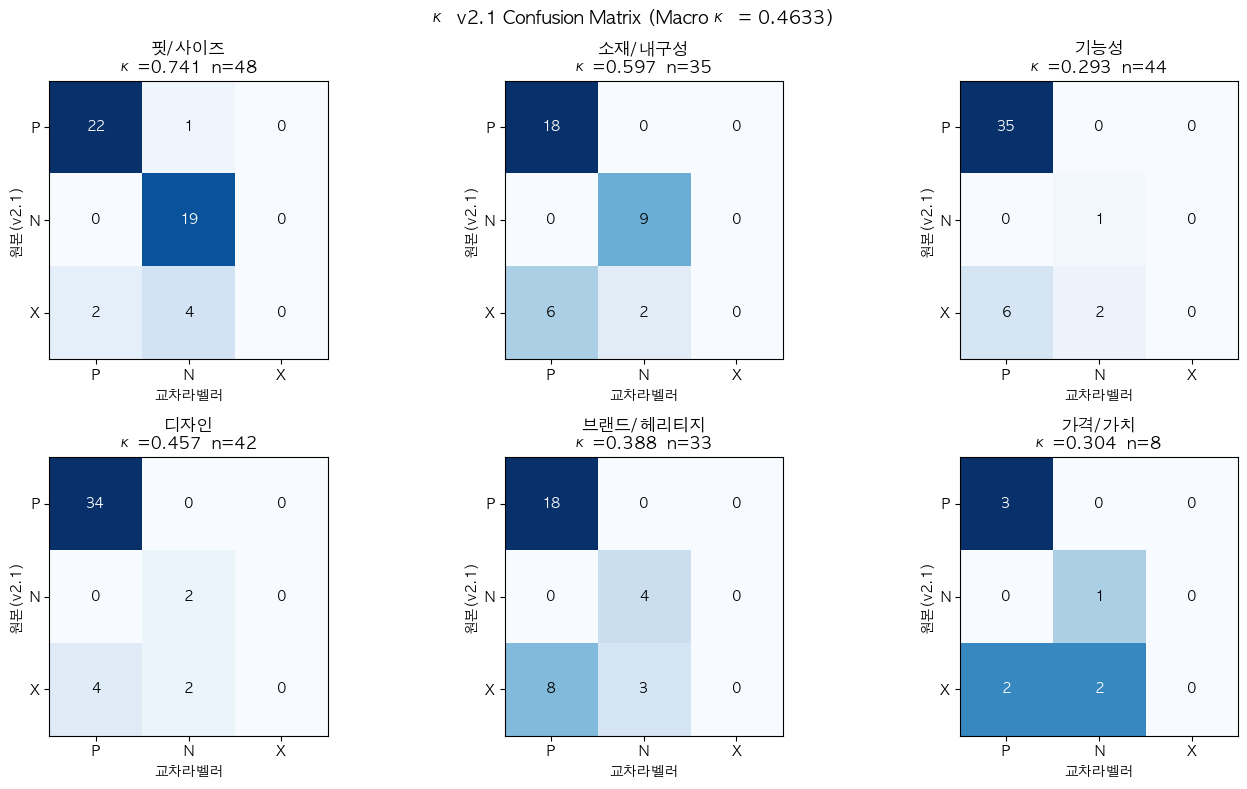


총 불일치: 44건
      속성 원본(v2.1) 교차  count
브랜드/헤리티지        X  P      8
     기능성        X  P      6
  소재/내구성        X  P      6
     디자인        X  P      4
   핏/사이즈        X  N      4
브랜드/헤리티지        X  N      3
   가격/가치        X  N      2
   가격/가치        X  P      2
     기능성        X  N      2
     디자인        X  N      2
  소재/내구성        X  N      2
   핏/사이즈        X  P      2
   핏/사이즈        P  N      1


In [7]:
# ── Cell 3: Mismatch 분석 + Confusion Matrix ─────────────────────
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

mismatch_rows = []

for i, asp in enumerate(ASPECTS):
    ax = axes[i]

    # 동일한 paired 데이터 재구성
    l1_gt500 = df_l1[df_l1['sample_idx'] > 500].set_index('sample_idx')
    l2_le500 = df_l2[df_l2['sample_idx'] <= 500].set_index('sample_idx')

    shared_a = l1_gt500.index.intersection(v21.index)
    shared_b = l2_le500.index.intersection(v21.index)

    orig_all  = pd.concat([v21.loc[shared_a, asp],  v21.loc[shared_b, asp]])
    cross_all = pd.concat([l1_gt500.loc[shared_a, asp], l2_le500.loc[shared_b, asp]])
    idx_all   = pd.concat([pd.Series(shared_a), pd.Series(shared_b)])

    valid = orig_all.notna() & cross_all.notna()
    y_orig  = orig_all[valid].values
    y_cross = cross_all[valid].values
    idx_valid = idx_all[valid.values].values

    # Mismatch 수집
    for j, (si, yo, yc) in enumerate(zip(idx_valid, y_orig, y_cross)):
        if yo != yc:
            row = df_v21[df_v21['sample_idx'] == si].iloc[0]
            mismatch_rows.append({
                'sample_idx': si, '속성': asp,
                '원본(v2.1)': yo, '교차': yc,
                'content_clean': row['content_clean'][:60]
            })

    # Confusion matrix
    labels = ['P', 'N', 'X']
    if len(y_orig) >= 5:
        cm = confusion_matrix(y_orig, y_cross, labels=labels)
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
        ax.set_xticklabels(labels); ax.set_yticklabels(labels)
        ax.set_xlabel('교차라벨러')
        ax.set_ylabel('원본(v2.1)')
        k_val = results[asp]['kappa']
        ax.set_title(f"{asp}\nκ={k_val:.3f}  n={valid.sum()}")
        for r in range(3):
            for c in range(3):
                ax.text(c, r, cm[r,c], ha='center', va='center',
                        color='white' if cm[r,c] > cm.max()/2 else 'black')
    else:
        ax.set_title(f"{asp}\n데이터 부족")
        ax.axis('off')

plt.suptitle(f'κ v2.1 Confusion Matrix (Macro κ = {macro_k:.4f})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Mismatch 상위 케이스 ──────────────────────────────────────────
df_mis = pd.DataFrame(mismatch_rows)
if len(df_mis):
    print(f"\n총 불일치: {len(df_mis)}건")
    print(df_mis.groupby(['속성', '원본(v2.1)', '교차']).size()
                .reset_index(name='count')
                .sort_values('count', ascending=False)
                .to_string(index=False))
else:
    print("불일치 없음 — 완벽한 일치!")


In [8]:
# Cell 4: 불일치 패턴 심층 분석
print(df_mis[df_mis['속성'].isin(['기능성', '브랜드/헤리티지'])]
      [['sample_idx', '속성', '원본(v2.1)', '교차', 'content_clean']]
      .to_string(index=False))


 sample_idx       속성 원본(v2.1) 교차                                                content_clean
        661      기능성        X  P                       중딩 아들도 젝시 양말이 편하다고 하여 같이 신을려고 재구매 했습니다
        728      기능성        X  N 저 신발 235나 240인데 양말이 저한테 좀 컸어요 그래서 남편 줬어요 저한테는 약간 쫀쫀하지 않은 느낌 
        784      기능성        X  N 제 발에는 안 어울려서 아쉽고 발목 부분이 거칠다고 해야하나 해서 마냥 편하진 않아요 그래도 색은 아주 예쁩
        858      기능성        X  P 너무 예쁘고 폭신폭신 합니다 싸이즈는 상품평에 정사이즈라고 많이들 하셨는데 전 좀 넉넉하더라고요 끈으로 조이
        863      기능성        X  P    너무 이뻐요 사이즈도 66입는데 딱입니다 세탁과 건조기 돌려도 변형없고 깔끔합니다 두루두루잘입을거같아요
        879      기능성        X  P 에샤페 디자인 넘 유니크하고 고급스러워요 사이즈가 품절이라 한치수 크게 했는데 편하게 잘 신게 되는것 같아요
        891      기능성        X  P      235신는데 240 잘 맞고 착용감도 좋아요발등에 닿는 부분이 뻣뻣해서 양말은 꼭 신어야 될것같아요
        911      기능성        X  P                              발바딕도 폭신하고 신발 바닥이 넘 이쁘고 디자인도 이뻐요
        520 브랜드/헤리티지        X  P                                    한달동안 만족스러웠습니다 좋은 제품 감사합니다
        524 브랜드/헤리티지        X  P 가슴이 빈약해서 셔링있는 제품으로 샀는데 이 제품